# 11_02.Semantic Network Analysis(의미 연결망 분석)
- Co-occurrence(동시발생빈도분석)
- https://lovit.github.io/nlp/2018/03/26/from_text_to_matrix
- https://cypision.github.io/deep-learning/text_analysis_basic_01_sckit_learn
- https://rainynotes.net/co-occurrence-matrix-visualization/


## 1.기본 package 설정

### 1.1 그래프 한글 인식 세팅

In [ ]:
# 단어 빈도 및 워드 클라우드에 한글 인식하기
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

#  *** 런타임 다시 시작

### 1.2 KoNLPY 세팅

In [ ]:
! pip install konlpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 48.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 465.3/465.3 kB 34.0 MB/s eta 0:00:00


### 1.3 package 설정

In [ ]:
## 1.기본
import numpy as np  # numpy 패키지 가져오기
import pandas as pd # pandas 패키지 가져오기
import matplotlib.pyplot as plt # 시각화 패키지 가져오기
import seaborn as sns # 시각화

## 2.데이터 전처리
import re                             # 정규식 모듈 임포트

## 3.형태소 처리
from konlpy.tag import Okt, Hannanum

## 4.DTM 만들기
from sklearn.feature_extraction.text import CountVectorizer

## 5.network graph
import networkx as nx

## 2.데이터 가져오기

### 2.1 구글 드라이브와 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
tm_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/tm.csv', encoding="cp949")
tm_df.head()

,no,구분,전공,본문
0,1,post,전공,코로나19라는 펜데믹 상황에서 \n사람이 모이면 안되는 상황인지라 실험을 진행하는데...
1,2,pre,교양,"3시간이라는 시간이 조금 길 수도 있겠다는 생각이 들지만, 필요한 정보를 많이 얻을..."
2,3,pre,교양,가장 특이하지만 또 가장 이상적인 모습의 교수님이었습니다 나무가 아닌 숲을 보는 수...
3,4,pre,교양,"각자의 생각이 다르고, 대학에 온 이유도 다를텐데, 동영상 ucc제작을 하는 이유를..."
4,5,pre,교양,강사님에 따라 강의 시간이 좋기도 하고 지루하기도 했다.


In [ ]:
tm_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1998 entries, 0 to 1997
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   no      1998 non-null   int64 
 1   구분      1998 non-null   object
 2   전공      1998 non-null   object
 3   본문      1998 non-null   object
dtypes: int64(1), object(3)
memory usage: 62.6+ KB


In [ ]:
tm_df['본문'].iloc[0]

'코로나19라는 펜데믹 상황에서 \n사람이 모이면 안되는 상황인지라 실험을 진행하는데 \n있어서 조금 불편함은 있었습니다만 최대한 서로 피해를 주지 않는 선에서 수업을 진행해주신 점이 좋았습니다. \n또한 수업 방식, 과제 제출 등에 대해 불편한 점이 생기면 바로 피드백을 주시고 해결점을 찾아주셔서 좋았고 수업 pdf 파일이 누락되는 일이 생겼을 때 늦더라도 꼭 올려주시는 것이 좋았습니다.  다만 공지가 조금 느리다는 생각이 들었고 공지가 조금 더 빨랐으면 좋았겠다 라는 생각이 들었습니다.\nKC 대학, 교수님, 교수, !!, Zoom 수업'

### 2.2 문서 전처리 및 동음이의어 정리
- 기본적인 문서 전처리 작업을 하고
- 단어빈도분석을 한 후에, 문제 있는 단어를 찾은 후에 정리

In [ ]:
tm_list = []

for i in range(len(tm_df)):
    text = tm_df['본문'].iloc[i]
    text = re.sub('[\x00-\x1F\x7F]', "", text)                # 제어문자[\n, \t] 제거 [[:cntrl:]]
    text = re.sub("[\W]", " ", text)                          # 구두점 등 제거 - 문자와 숫자만 저장
    #text = re.sub("[^\D]", " ", text)                         # 숫자제거
    text = re.sub('(Zoom 수업|Zoom수업|줌 수업)', '줌수업', text)
    text = re.sub('강의', '수업', text)
    tm_list.append(text)

# 2개 단어를 한단어로 통합
# re.sub('(강서 대학교|강서대학|강서 대학)', '강서대학교', text)

# 같은 단어를 한 단어로 변경
# re.sub("공부\\w*", "공부", word)
# re.sub("\\w*\\습니\\w*", "삭제", word)

In [ ]:
tm_list[0]

'코로나19라는 펜데믹 상황에서 사람이 모이면 안되는 상황인지라 실험을 진행하는데 있어서 조금 불편함은 있었습니다만 최대한 서로 피해를 주지 않는 선에서 수업을 진행해주신 점이 좋았습니다  또한 수업 방식  과제 제출 등에 대해 불편한 점이 생기면 바로 피드백을 주시고 해결점을 찾아주셔서 좋았고 수업 pdf 파일이 누락되는 일이 생겼을 때 늦더라도 꼭 올려주시는 것이 좋았습니다   다만 공지가 조금 느리다는 생각이 들었고 공지가 조금 더 빨랐으면 좋았겠다 라는 생각이 들었습니다 KC 대학  교수님  교수      줌수업'

## 3.형태소로 분리 및 불용어제거
- https://konlpy.org/ko/latest/api/konlpy.tag/
- 명사와 동사 추출
- 한단어 삭제
- 동사만 추출은 부록 참고
- 불용어 제거: 단어빈도분석을 한 후에, 문제 있는 단어를 찾은 후에 불용어 제거

In [ ]:
# 명사 및 동사 추출을 함수로 만들기
def okt_token(text):
    okt = Okt()
    words_list = []
    stop_words = ["하다", "있다", "되어다"]
    morp = okt.pos(text, stem=True)                              # stem = 동사 원형 추출
    #명사와 동사 추출, 한 글자 단어 삭제, 불용어 제거
    for word, tag in morp:
        if ((tag == 'Noun' or tag == 'Verb' or tag == 'Adjective')
             and (len(word) > 1)
             and (word not in stop_words)):
            words_list.append(word)
    return words_list

## 4.Document-Term Matrix 만들기
- https://cypision.github.io/deep-learning/text_analysis_basic_01_sckit_learn/

### 4.1 DTM 만들기
- 2중 list를 한 개의 list로 통합하기 위해 명사 동사 추출을 별도로 진행

In [ ]:
# matrix 만들기
cv = CountVectorizer(ngram_range=(1,1),        # 1:1 단일어로
                     tokenizer = okt_token)    # 한글 형태소 분석기로 세팅

In [ ]:
dtm_counts = cv.fit_transform(tm_list)

In [ ]:
dtm_df = pd.DataFrame(dtm_counts.todense().tolist(),
                      columns = cv.get_feature_names_out())
dtm_df

,가게,가까이,가깝다,가끔,가능성,가능하다,가다,가도,가독성,가득하다,...,흥미,흥미롭다,희망,히브리어,힐링,힘내다,힘드다,힘들다,힘들엇습니,힘쓰다
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1993,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1994,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### 4.2 Term to Term Matrix
- 그래프를 그리기 위해 TTM으로 변환

In [ ]:
ttm_counts = (dtm_counts.T * dtm_counts)
ttm_counts.setdiag(0)

In [ ]:
ttm_df = pd.DataFrame(ttm_counts.todense().tolist(),
                      columns = cv.get_feature_names_out(),
                      index = cv.get_feature_names_out())
ttm_df

,가게,가까이,가깝다,가끔,가능성,가능하다,가다,가도,가독성,가득하다,...,흥미,흥미롭다,희망,히브리어,힐링,힘내다,힘드다,힘들다,힘들엇습니,힘쓰다
가게,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
가까이,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
가깝다,0,0,0,0,0,0,3,0,0,0,...,0,0,0,0,0,0,0,0,0,0
가끔,0,0,0,0,0,0,3,0,0,0,...,1,0,0,0,0,0,1,0,0,0
가능성,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
힘내다,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
힘드다,0,0,0,1,0,0,1,0,1,1,...,0,0,0,0,0,0,0,1,0,1
힘들다,0,0,0,0,0,0,5,0,0,0,...,1,1,2,0,0,0,1,0,0,0
힘들엇습니,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 5 Centrality 계산

In [ ]:
# import networkx as nx

g = nx.from_pandas_adjacency(ttm_df)

In [ ]:
# degree_centrality
dc = nx.degree_centrality(g)
dc_df = sorted(dc.items(), key=lambda x: x[1], reverse=True)
dc_df = pd.DataFrame(list(dc_df)[:100],
                     columns = ["word","dc"])
dc_df

,word,dc
0,수업,0.781732
1,좋다,0.677165
2,교수,0.668976
3,학생,0.553386
4,같다,0.533858
...,...,...
95,해보다,0.142677
96,가지,0.141417
97,계획,0.141417
98,안되다,0.141417


In [ ]:
# closeness_centrality: 1:30

cc = nx.closeness_centrality(g)
cc_df = sorted(cc.items(), key=lambda x: x[1], reverse=True)
cc_df = pd.DataFrame(list(cc_df)[:100],
                     columns = ["word","cc"])
cc_df

,word,cc
0,수업,0.820283
1,좋다,0.755256
2,교수,0.750418
3,학생,0.690312
4,같다,0.681243
...,...,...
95,해보다,0.537014
96,안되다,0.536740
97,가지,0.536649
98,계획,0.536467


In [ ]:
# betweenness_centrality : 5분 소요
bc = nx.betweenness_centrality(g,
                               normalized = True,
                               endpoints = False)
degree_betweenness = nx.betweenness_centrality(g)
bc_df = sorted(bc.items(), key=lambda x: x[1], reverse=True)
bc_df = pd.DataFrame(list(bc_df)[:100],
                     columns = ["word","bc"])
bc_df

,word,bc
0,수업,0.115100
1,좋다,0.079970
2,교수,0.073169
3,같다,0.038390
4,학생,0.036124
...,...,...
95,덕분,0.001081
96,올리다,0.001074
97,재밌다,0.001071
98,참여,0.001070


In [ ]:
# centrality 통합표 만들기
temp = pd.merge(dc_df, cc_df, how = "outer", on = "word")
centrality_df = pd.merge(temp, bc_df, how = "outer", on = "word")
centrality_df

,word,dc,cc,bc
0,수업,0.781732,0.820283,0.115100
1,좋다,0.677165,0.755256,0.079970
2,교수,0.668976,0.750418,0.073169
3,학생,0.553386,0.690312,0.036124
4,같다,0.533858,0.681243,0.038390
...,...,...,...,...
103,오다,NaN,NaN,0.001321
104,올려주다,NaN,NaN,0.001243
105,관심,NaN,NaN,0.001238
106,올리다,NaN,NaN,0.001074


## 6.Network Graph

In [ ]:
# network 생성

g = nx.from_pandas_adjacency(ttm_df)

In [ ]:
print(g.number_of_nodes())
print(g.number_of_edges())

3176
145153


In [ ]:
# edge 숫자 조정
# https://frhyme.github.io/python-lib/networkx-graph-control/

edge_weight = 100
g_edge = nx.Graph()

g_edge.add_nodes_from(g.nodes(data=True))
edges = filter(lambda e: True if e[2]['weight'] >= edge_weight else False, g.edges(data=True))
g_edge.add_edges_from(edges)

# neighbor가 없는 isolated node를 모두 지운다.
for n in g.nodes():
    if len(list(nx.all_neighbors(g_edge, n)))==0:
        g_edge.remove_node(n)

In [ ]:
print(g_edge.number_of_nodes())
print(g_edge.number_of_edges())

76
174


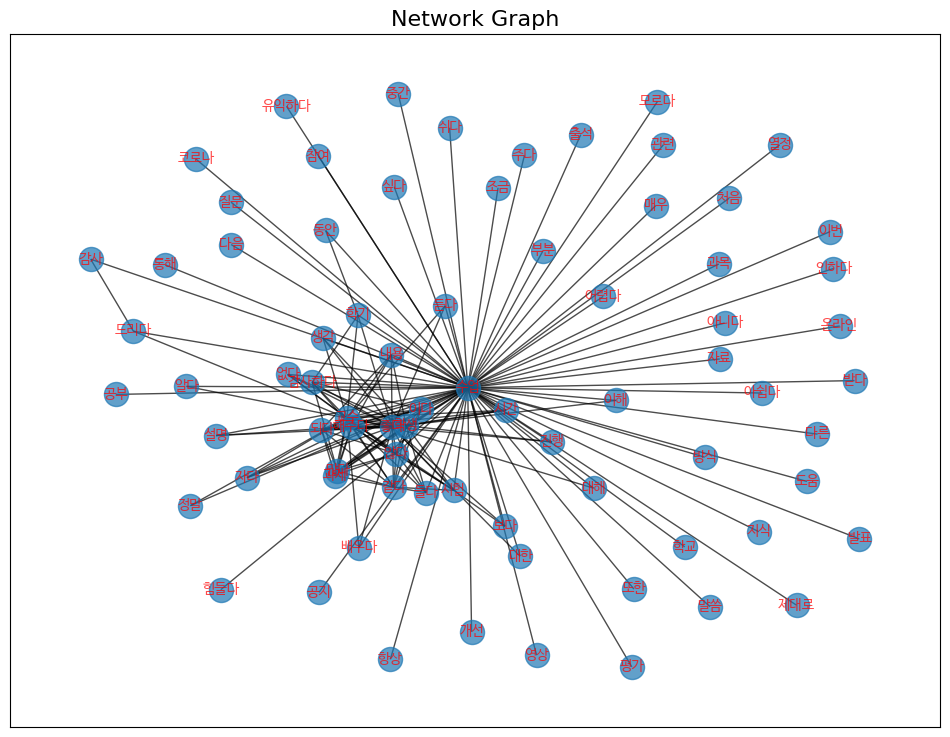

In [ ]:
plt.figure(figsize=(12, 9))
plt.title('Network Graph', fontsize = 16)
nx.draw_networkx(g_edge,
                 pos = nx.spring_layout(g_edge),
                 font_color = "red",
                 font_family = "NanumBarunGothic",
                 with_labels = True,
                 font_size = 10,
                 cmap = plt.cm.Blues,
                 alpha=0.7)
plt.show()
# nx.spring_layout(g)
# nx.kamada_kawai_layout(g)
# nx.circular_layout(g)
# nx.random_layout((g)
# nx.spectral_layout(g)
# nx.fruchterman_reingold_layout

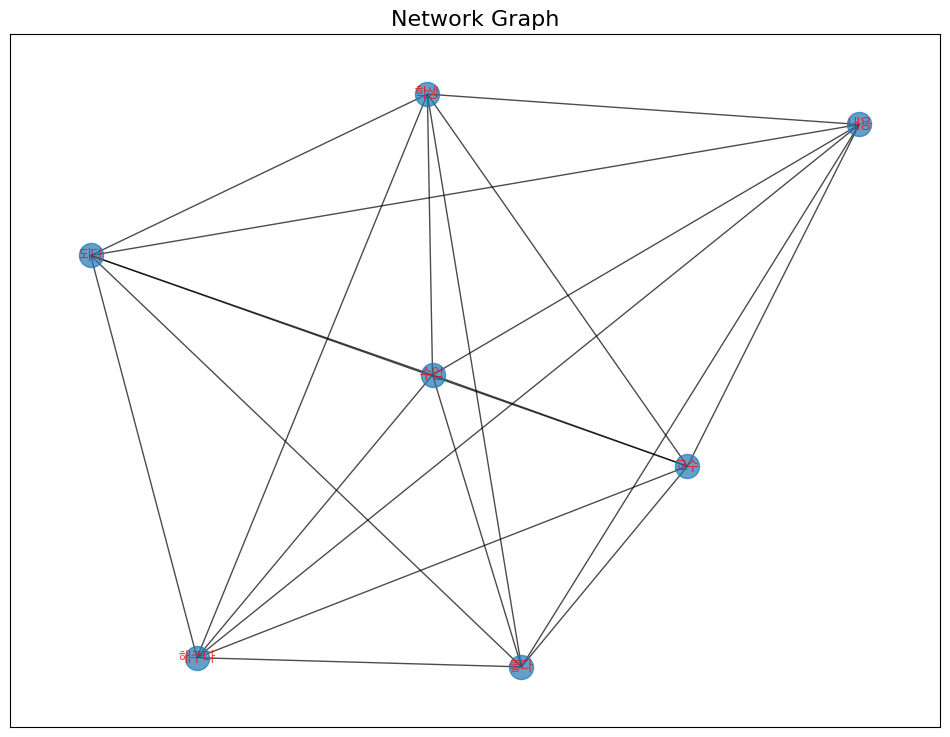

In [ ]:
# ego network

g_ego = nx.ego_graph(g_edge, '내용')
plt.figure(figsize=(12, 9))
plt.title('Network Graph', fontsize = 16)
nx.draw_networkx(g_ego,
                 pos = nx.spring_layout(g_ego),
                 font_color = "red",
                 font_family = "NanumBarunGothic",
                 with_labels = True,
                 font_size = 10,
                 cmap = plt.cm.Blues,
                 alpha=0.7)
plt.show()

## 부록: degree 수로 축소하는 방법

In [ ]:
from collections import defaultdict
node_dictionary = defaultdict(int)

for n in g.nodes():
    node_dictionary[n] = nx.degree(g, n)

nx.set_node_attributes(g, node_dictionary, 'degrees')

remove = [node for node,degree in dict(g.degree()).items() if degree < 500]
g.remove_nodes_from(remove)

## 부록 correlation 구하기

In [ ]:
from scipy.spatial.distance import pdist, squareform
from itertools import combinations
from operator import itemgetter

term_corr = pdist(ttm_counts.toarray(), metric='correlation')
term_corr_m = squareform(term_corr)
term_corr_m

array([[0.00000000e+00, 1.37570515e-01, 6.22284393e-01, 5.08163641e-01,
        3.75080222e-01, 2.93438195e-01, 8.47136015e-01, 4.49453604e-01,
        6.41422292e-02, 4.49453604e-01, 7.88695849e-02, 7.88695849e-02,
        4.33746921e-01, 1.85056688e-01, 2.69733725e-01, 1.06727080e+00,
        2.67101345e-01, 5.96939181e-01, 2.49629030e-01, 5.56465245e-02,
        5.20825657e-01, 4.49453604e-01, 5.91732075e-01, 5.62739783e-01,
        2.39014144e-01, 2.67320945e-01, 6.41422292e-02, 4.05655995e-01,
        5.91732075e-01, 2.30792936e-01],
       [1.37570515e-01, 0.00000000e+00, 4.19768173e-01, 8.60466798e-01,
        3.56875980e-01, 4.66317658e-01, 9.01228825e-01, 7.61401447e-01,
        7.39534335e-02, 7.61401447e-01, 1.94599880e-01, 1.94599880e-01,
        6.95102140e-01, 4.65019015e-01, 3.25924955e-01, 1.21431250e+00,
        9.59943738e-02, 7.04978504e-01, 2.64077692e-01, 2.13751841e-01,
        6.35749904e-01, 7.61401447e-01, 5.57445359e-01, 7.01169889e-01,
        3.53968688e-01,